# Obstacle

### Imports and setup

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# from external.preconditioning.model_architecture import GeneralNet
# from external.preconditioning.optimizers import HandNGD 
from GINN.ph.ph_manager import PHManager
# from GINN.ph.ph_distributed import calc_3d_ph_4d_array
from models.net_w_partials import NetWithPartials

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [56]:
import torch

n_x = 100
n_y = 50

# Create linspace grid
x = torch.linspace(-1.0, 1.0, n_x)
y = torch.linspace(-0.5, 0.5, n_y)
X, Y = torch.meshgrid(x, y, indexing='ij')
pts = torch.stack([X.ravel(), Y.ravel()], dim=1)

dist = torch.norm(pts, dim=1)
mask_dist = dist <= 0.1
mask_inside_bounds = (torch.abs(pts[:, 0]) > 0.9) | (torch.abs(pts[:, 1]) > 0.4)
mask = mask_dist | mask_inside_bounds

pts_not_design_region = pts[mask]
pts_design_region = pts[~mask]

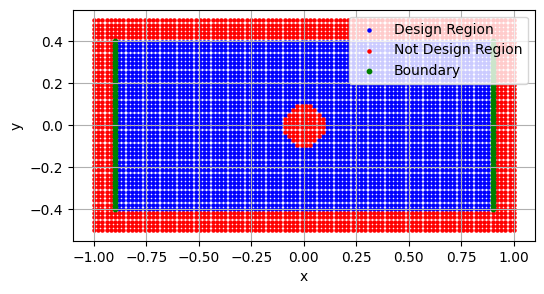

In [57]:
x_boundary_left = torch.full((n_y,), -0.9)
x_boundary_right = torch.full((n_y,), 0.9)
y_boundary = torch.linspace(-0.4, 0.4, n_y)

pts_boundary_left = torch.stack([x_boundary_left, y_boundary], dim=1)
pts_boundary_right = torch.stack([x_boundary_right, y_boundary], dim=1)

pts_boundary = torch.cat([pts_boundary_left, pts_boundary_right], dim=0)

# Plot all points
plt.figure(figsize=(6, 3))
plt.scatter(pts_design_region[:, 0].cpu(), pts_design_region[:, 1].cpu(), s=5, color='blue', label="Design Region")
plt.scatter(pts_not_design_region[:, 0].cpu(), pts_not_design_region[:, 1].cpu(), s=5, color='red', label="Not Design Region")
plt.scatter(pts_boundary[:, 0].cpu(), pts_boundary[:, 1].cpu(), s=10, color='green', label="Boundary")
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


In [58]:
from torch.func import vmap, jacrev, jacfwd, functional_call
from torch.nn.functional import softplus
class GeneralResNet(nn.Module):
    def __init__(self, ks, act=softplus):
        super(GeneralResNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.params = dict(self.named_parameters())
        self.act = act

    def forward(self, x, z=torch.zeros([1,0])):
        x = self.act(self.fcs[0](x))
        for i in range(2,self.D):
            # Note: as per 7.12.2023 it throws the following error if x += ... is used
            # Exception has occurred: RuntimeError       (note: full exception trace is shown but execution is paused at: _run_module_as_main)
            # one of the variables needed for gradient computation has been modified by an inplace operation: [torch.cuda.FloatTensor [512, 2, 64]],
            x = x + self.act(self.fcs[i-1](x))
        x = self.fcs[self.D-1](x)
        return x
    def f(self, params, x):
        """Wrapper for functional_call."""
        return functional_call(self, params, x)
    def f(self, params, x):
        """Wrapper for functional_call."""
        return functional_call(self, params, x)

    def _f_x(self, params, x):
        """Jacobian of f with respect to input x (non-vectorized, private)."""
        return jacrev(self.f, argnums=1)(params, x)

    def vf_x(self, params, x):
        """Vectorized Jacobian of f with respect to input x."""
        return vmap(self._f_x, in_dims=(None, 0), out_dims=(0))(params, x)

    def _f_xx(self, params, x):
        """Hessian of f with respect to input x (non-vectorized, private)."""
        return jacfwd(self._f_x, argnums=1)(params, x)

    def vf_xx(self, params, x):
        """Vectorized Hessian of f with respect to input x."""
        return vmap(self._f_xx, in_dims=(None, 0), out_dims=(0))(params, x)

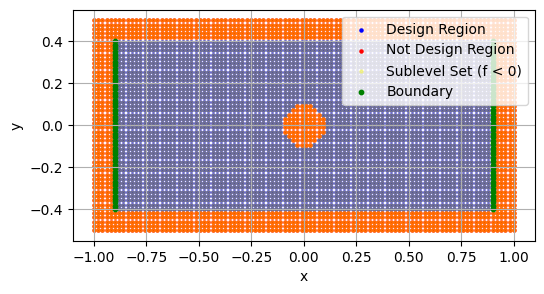

In [59]:
# model = GeneralResNet(ks=[2, 512, 512, 512, 1])
model = GeneralResNet(ks=[2, 32, 32, 1])

with torch.no_grad():
    values = model(pts).squeeze()

pts_sublevel = pts[values <= 0]

plt.figure(figsize=(6, 3))
plt.scatter(pts_design_region[:, 0].cpu(), pts_design_region[:, 1].cpu(), s=5, color='blue', label="Design Region")
plt.scatter(pts_not_design_region[:, 0].cpu(), pts_not_design_region[:, 1].cpu(), s=5, color='red', label="Not Design Region")
plt.scatter(pts_sublevel[:, 0].cpu(), pts_sublevel[:, 1].cpu(), s=5, color='yellow', alpha=0.3, label="Sublevel Set (f < 0)")
plt.scatter(pts_boundary[:, 0].cpu(), pts_boundary[:, 1].cpu(), s=10, color='green', label="Boundary")
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()



In [60]:
netp = NetWithPartials.create_from_model(model, nz=1, nx=2)#, max_group_size=1e8)
bounds = torch.tensor([[-1,1], [-0.5,0.5]])

## Define the function to check if query points a are inside the envelope, which in this case is trivially the bounds.
## Since the query points will be in the bounds per construction, we could've also just returned True without checking.
def is_inside_envelope(a: torch.Tensor):
    """Get mask for points which are inside the envelope"""
    is_inside_mask = (
        (a[:, 0] >= bounds[0, 0]) & 
        (a[:, 0] <= bounds[0, 1]) & 
        (a[:, 1] >= bounds[1, 0]) & 
        (a[:, 1] <= bounds[1, 1])
        )
    return is_inside_mask


ph_manager = PHManager(
    mp_pool = None,
    nx = 2, ## dimension of input
    bounds = bounds, ## bounds of the rectangular domain, list of (min, max) pairs for each coordinate
    netp = netp, ## model
    scc_n_grid_points = 128, ## nof grid points along each dimension
    func_inside_envelope = is_inside_envelope, ## a function to mask the points outside the envelope as these would create illegal connections. In the obstacle problem, we do not really need this.
    ph_1_hole_level = 0.1, ## persistence of holes. Ignore if only ph_loss_maxdim=0 (at most 0-PH ie connectedness)
    ph_loss_target_betti = [1,0,0], ## Target Betti-numers for each dim-PH. Connectedness means 1 for dim=0. Others can be ignored if ph_loss_maxdim=0.
    iso_level = 0, ## level defining the boundary.  This also enforces the thickness of the thinest feature for an SDF. 
    ph_loss_sub0_points = False,
    ph_loss_super0_points = False,
    simjeb_root_dir = "", ## leave empty
    problem_str= "", ## leave empty
    ph_loss_maxdim=0, ## connectedness only
    is_density=False, ## is the implicit function a density field? (no for an SDF)
)

success, loss_scc, _, _ = ph_manager.calc_ph_loss_cripser(z=torch.zeros([1,0]))
print(success, loss_scc)

False tensor(0., device='cuda:0')


  0%|          | 0/10000 [00:00<?, ?it/s]

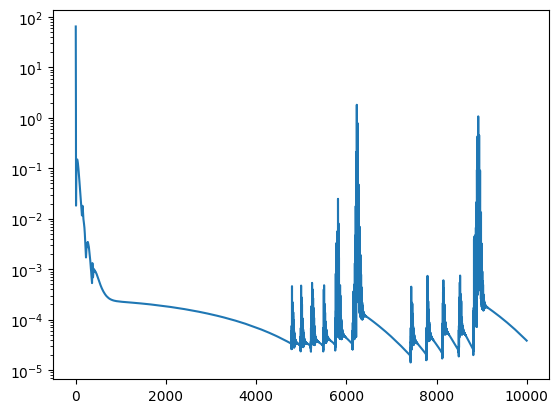

In [61]:
loss_weights = {"interface": 10.0, "design_region": 1.0, "normal": 1.0, "connectedness": 100.0}
params = model.params
loss_over_iters = {}
true_normal_left = torch.tensor([-1.0, 0.0])
true_normal_right = torch.tensor([1.0, 0.0])
pts_connectedness = torch.tensor([[0.0, 0.2]])
# Adam:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in (pbar:=trange(10000)):
    optim.zero_grad()
    # Interface
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()
    # Design Region
    f_values_not_dr = model.f(params, pts_not_design_region)
    loss_design_region = 0.5 * (f_values_not_dr[f_values_not_dr < 0.0]).square().sum()
    # Normal
    grad_left = model.vf_x(params, pts_boundary_left).squeeze(1)
    normal_left = grad_left / (grad_left.square().sum(1).sqrt().view(-1, 1))
    grad_right = model.vf_x(params, pts_boundary_right).squeeze(1)
    normal_right = grad_right / (grad_right.square().sum(1).sqrt().view(-1, 1))
    loss_normal_left = 0.5 * (normal_left - true_normal_left).square().sum(1).mean()
    loss_normal_right = 0.5 * (normal_right - true_normal_right).square().sum(1).mean()
    loss_normal = loss_normal_left + loss_normal_right
    # Connectedness
    # loss_connectedness = 0.5 * (model.f(params, pt_connectedness) + 1.0).square().mean()
    _, loss_connectedness, _, _ = ph_manager.calc_ph_loss_cripser(z=torch.zeros([1,0]))
           
    loss = (
        loss_weights["interface"] * loss_interface
        + loss_weights["design_region"] * loss_design_region
        + loss_weights["normal"] * loss_normal
        + loss_weights["connectedness"] * loss_connectedness
    )

    loss.backward()
    
    with torch.no_grad():
        loss_metric = loss_interface + loss_design_region
        loss_over_iters[i] = loss_metric.item()     

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"design_region: {loss_design_region.item():.2e} "
                            f"normal: {loss_normal.item():.2e} "
                            f"connectedness: {loss_connectedness.item():.2e} "
                            )
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

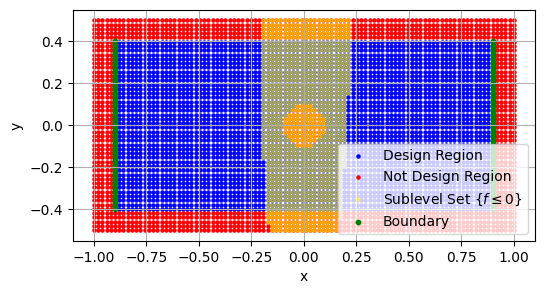

In [62]:
with torch.no_grad():
    values = model(pts).squeeze()

pts_sublevel = pts[values <= 0]

# Plot the sublevel points
plt.figure(figsize=(6, 3))
plt.scatter(pts_design_region[:, 0].cpu(), pts_design_region[:, 1].cpu(), s=5, color='blue', label="Design Region")
plt.scatter(pts_not_design_region[:, 0].cpu(), pts_not_design_region[:, 1].cpu(), s=5, color='red', label="Not Design Region")
plt.scatter(pts_sublevel[:, 0].cpu(), pts_sublevel[:, 1].cpu(), s=5, color='yellow', alpha=0.5, label="Sublevel Set $\{f \leq 0\}$")
plt.scatter(pts_boundary[:, 0].cpu(), pts_boundary[:, 1].cpu(), s=10, color='green', label="Boundary")
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

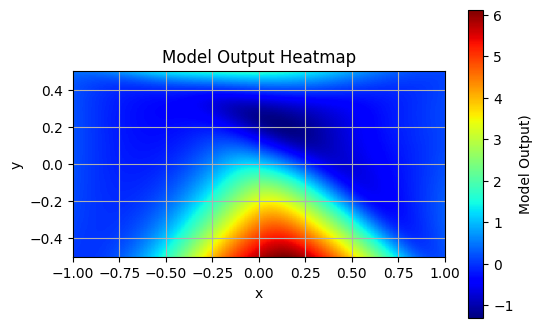

In [54]:
num_points = 100

x_min, x_max = pts[:, 0].min().item(), pts[:, 0].max().item()
y_min, y_max = pts[:, 1].min().item(), pts[:, 1].max().item()

x_lin = torch.linspace(x_min, x_max, num_points)
y_lin = torch.linspace(y_min, y_max, num_points)
X, Y = torch.meshgrid(x_lin, y_lin, indexing="xy")
grid_pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    Z = model(grid_pts).cpu().numpy().reshape(num_points, num_points)

plt.figure(figsize=(6, 4))
plt.imshow(Z, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='jet', alpha=1.0)


# Plot formatting
plt.colorbar(label="Model Output)")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.grid(True)
plt.title("Model Output Heatmap")
plt.show()


In [ ]:
# true_normal_left = torch.tensor([-1.0, 0.0], dtype=torch.float64)
# true_normal_right = torch.tensor([1.0, 0.0], dtype=torch.float64)
# grad_left = model.vf_x(params, pts_boundary_left).squeeze(1)
# normal_left = grad_left / (grad_left.square().sum(1).sqrt().view(-1, 1))
# grad_right = model.vf_x(params, pts_boundary_right).squeeze(1)
# normal_right = grad_right / (grad_right.square().sum(1).sqrt().view(-1, 1))

# loss_left = 0.5 * (normal_left - true_normal_left).square().sum(1).mean()
# loss_right = 0.5 * (normal_right - true_normal_right).square().sum(1).mean()
# loss_normal = loss_left + loss_right
# loss_normal = 0
 #old loss:
# normal_scp_left = model.vf_x(params, pts_boundary_left).squeeze(1) @ torch.tensor([-1,0], dtype=torch.float64)
# normal_scp_right = model.vf_x(params, pts_boundary_left).squeeze(1) @ torch.tensor([1,0], dtype=torch.float64)
# normal_scp = torch.cat([normal_scp_left, normal_scp_right])
# loss_normal = 0.5*(normal_scp - torch.ones_like(normal_scp)).square().mean()

# include eikonal or not?
# loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()


# with torch.no_grad():
#     values = model(pts).squeeze()
# pts_sublevel = pts[values <= 0]
# dists = torch.cdist(pts_not_design_region, pts_sublevel)
# mask_intersection = (dists < 1e-6).any(dim=1)    
# pts_design_region = pts_not_design_region[mask_intersection]

# if pts_design_region.numel() == 0:
#     loss_design_region = torch.tensor(0.0, dtype=torch.float64)
# else:
#     loss_design_region = 0.5 * model.f(params, pts_design_region).square().mean()

# loss_design_region = 0.5 * model.f(params, pts_not_design_region).square().mean()